In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [5]:
# 1. Load the data (using '../' to go back one folder level to 'data')
sales_df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\Zidio Development\Month 1\data\sales_daily.csv')
sku_df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\Zidio Development\Month 1\data\sku_master.csv')

# 2. Merge the sales and product details together based on the 'SKU' column
merged_df = pd.merge(sales_df, sku_df, on='SKU', how='left')

# 3. Calculate Total Revenue by Category to see what's making money
category_revenue = merged_df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print("--- TOTAL REVENUE BY CATEGORY ---")
print(category_revenue)

# 4. Let's check on our "Problem Child" (Product 002) that loses money on every sale!
sku002_sales = merged_df[merged_df['SKU'] == 'SKU002']['Units_Sold'].sum()
print(f"\nTotal units sold of SKU002 (Negative Margin Item): {sku002_sales}")

--- TOTAL REVENUE BY CATEGORY ---
Category
Home Decor    8.884681e+08
Furniture     6.033905e+08
Storage       5.819274e+08
Kitchen       5.635346e+08
Lighting      4.587362e+08
Name: Revenue, dtype: float64

Total units sold of SKU002 (Negative Margin Item): 7412


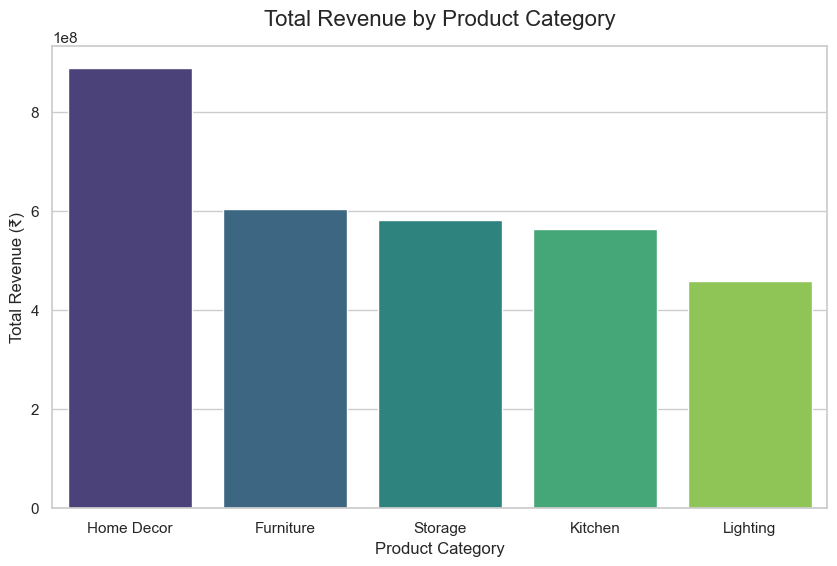

In [6]:
# 1. Set the visual style for the chart
sns.set_theme(style="whitegrid")

# 2. Set the size of the canvas
plt.figure(figsize=(10, 6))

# 3. Create a bar plot for the Category Revenue we calculated earlier
ax = sns.barplot(
    x=category_revenue.index, 
    y=category_revenue.values, 
    hue=category_revenue.index, # Added this to satisfy the new requirement
    palette="viridis"
)

# 4. Add clear titles and labels for the report
plt.title('Total Revenue by Product Category', fontsize=16, pad=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)

# 5. Display the chart
plt.show()

In [7]:
# 1. Load the calendar and inventory files (update the path if necessary)
calendar_df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\Zidio Development\Month 1\data\calendar.csv')
inventory_df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\Zidio Development\Month 1\data\inventory_snapshots.csv')

# 2. Inspect Calendar Data
print("--- CALENDAR DATA INFO ---")
print(f"Shape: {calendar_df.shape}")
display(calendar_df.head(3))
print("\nMissing values in Calendar:\n", calendar_df.isnull().sum())

# 3. Inspect Inventory Snapshots Data
print("\n--- INVENTORY SNAPSHOTS DATA INFO ---")
print(f"Shape: {inventory_df.shape}")
display(inventory_df.head(3))
print("\nMissing values in Inventory:\n", inventory_df.isnull().sum())

--- CALENDAR DATA INFO ---
Shape: (731, 11)


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,NaN,0,NaN
2,2024-01-03,2024,1,Q1,1,Wednesday,0,Winter,NaN,0,NaN



Missing values in Calendar:
 date                 0
year                 0
month                0
quarter              0
week                 0
day_of_week          0
is_weekend           0
season               0
holiday            723
is_holiday           0
promotion_event    656
dtype: int64

--- INVENTORY SNAPSHOTS DATA INFO ---
Shape: (4800, 8)


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40
2,2024-01-01,SKU003,34,23,14,6,20,209060.22



Missing values in Inventory:
 Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64


In [8]:
# Fill the blank (NaN) holidays and promotions with the word "None"
calendar_df['holiday'] = calendar_df['holiday'].fillna('None')
calendar_df['promotion_event'] = calendar_df['promotion_event'].fillna('None')

# Verify the fix! We should now see 0 missing values.
print("--- Missing values after cleaning ---")
print(calendar_df.isnull().sum())

--- Missing values after cleaning ---
date               0
year               0
month              0
quarter            0
week               0
day_of_week        0
is_weekend         0
season             0
holiday            0
is_holiday         0
promotion_event    0
dtype: int64


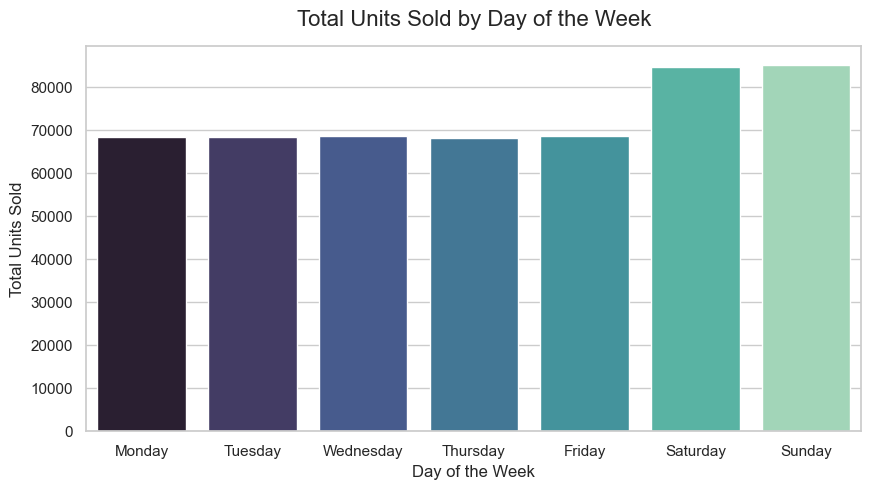

In [9]:
# 1. Standardize the column names so they match (Date vs date)
calendar_df = calendar_df.rename(columns={'date': 'Date'})

# 2. Merge the Sales transactions with the Calendar metadata
sales_calendar_df = pd.merge(sales_df, calendar_df, on='Date', how='left')

# 3. Calculate total units sold by Day of the Week and order them logically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_sales = sales_calendar_df.groupby('day_of_week')['Units_Sold'].sum().reindex(days_order)

# 4. Plot the trend!
plt.figure(figsize=(10, 5))
sns.barplot(
    x=day_of_week_sales.index, 
    y=day_of_week_sales.values, 
    hue=day_of_week_sales.index, 
    palette="mako", 
    legend=False
)
plt.title('Total Units Sold by Day of the Week', fontsize=16, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.show()

In [10]:
# 1. Convert the 'Date' column to actual datetime objects
sales_calendar_df['Date'] = pd.to_datetime(sales_calendar_df['Date'])

# 2. Sort the data chronologically by SKU and Date (Critical for time-series forecasting!)
df_features = sales_calendar_df.sort_values(by=['SKU', 'Date']).copy()

# 3. Create Lag Features (What were the sales 1 day ago? What about 7 days ago?)
df_features['Lag_1_Day'] = df_features.groupby('SKU')['Units_Sold'].shift(1)
df_features['Lag_7_Days'] = df_features.groupby('SKU')['Units_Sold'].shift(7)

# 4. Create Rolling Averages (What is the average sales trend over the last 7 days?)
df_features['Rolling_7_Day_Avg'] = df_features.groupby('SKU')['Units_Sold'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

# 5. Since shifting data creates blanks (NaNs) for the very first few days, let's fill them with 0
df_features.fillna(0, inplace=True)

# 6. Let's peek at our new predictive features for a single product!
preview = df_features[df_features['SKU'] == 'SKU001'][['Date', 'SKU', 'Units_Sold', 'Lag_1_Day', 'Lag_7_Days', 'Rolling_7_Day_Avg']]
print("--- MACHINE LEARNING FEATURES GENERATED ---")
display(preview.head(10))

--- MACHINE LEARNING FEATURES GENERATED ---


,Date,SKU,Units_Sold,Lag_1_Day,Lag_7_Days,Rolling_7_Day_Avg
0,2024-01-01,SKU001,5,0.0,0.0,5.000000
50,2024-01-02,SKU001,13,5.0,0.0,9.000000
100,2024-01-03,SKU001,12,13.0,0.0,10.000000
150,2024-01-04,SKU001,23,12.0,0.0,13.250000
200,2024-01-05,SKU001,16,23.0,0.0,13.800000
250,2024-01-06,SKU001,18,16.0,0.0,14.500000
300,2024-01-07,SKU001,19,18.0,0.0,15.142857
350,2024-01-08,SKU001,12,19.0,5.0,16.142857
400,2024-01-09,SKU001,10,12.0,13.0,15.714286
450,2024-01-10,SKU001,11,10.0,12.0,15.571429


Training the Random Forest model... 🚀

--- MODEL EVALUATION RESULTS ---
Mean Absolute Error (MAE): 3.48 units
Root Mean Squared Error (RMSE): 4.56 units


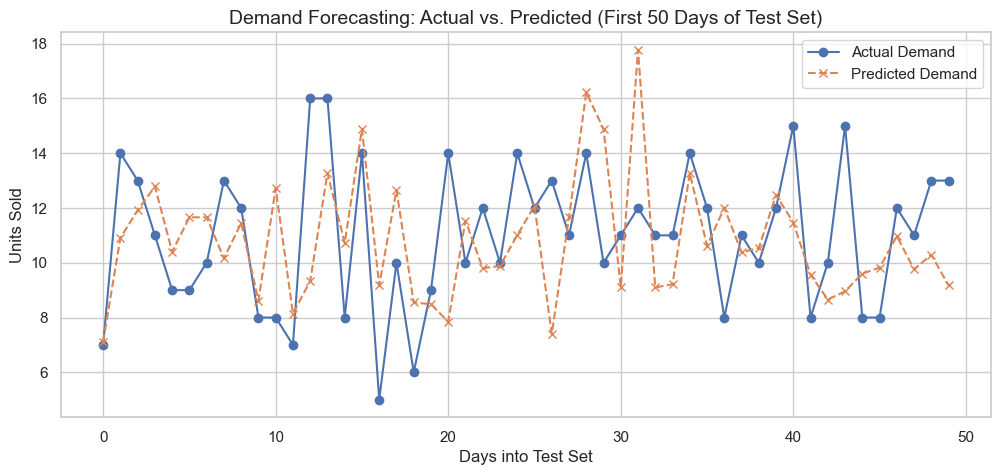

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Define our Features (X) and Target (y)
# We want to predict 'Units_Sold' using our new lag features
features = ['Lag_1_Day', 'Lag_7_Days', 'Rolling_7_Day_Avg']
X = df_features[features]
y = df_features['Units_Sold']

# 2. Time-Series Split (Train on the past, Test on the future)
# We set shuffle=False because time order matters!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 3. Initialize and Train the Machine Learning Model
print("Training the Random Forest model... 🚀")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make Predictions on the Test Set
predictions = rf_model.predict(X_test)

# 5. Evaluate the Model's Accuracy
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\n--- MODEL EVALUATION RESULTS ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")

# 6. Quick Visual Check: Actual vs. Predicted for the first 50 test days
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:50], label='Actual Demand', marker='o')
plt.plot(predictions[:50], label='Predicted Demand', marker='x', linestyle='--')
plt.title('Demand Forecasting: Actual vs. Predicted (First 50 Days of Test Set)', fontsize=14)
plt.xlabel('Days into Test Set')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

--- INVENTORY RISK SUMMARY (As of 2025-12-01) ---
Risk_Status
Healthy          121
Stockout Risk     64
Overstock         15
Name: count, dtype: int64


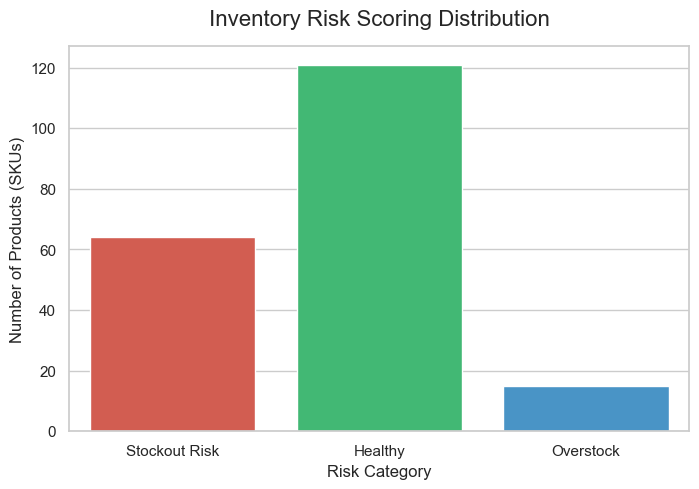


--- URGENT: CRITICAL STOCKOUT ITEMS ---


,SKU,Current_Stock,Reorder_Point
4606,SKU007,207,237
4608,SKU009,75,131
4611,SKU012,47,58
4614,SKU015,187,265
4616,SKU017,95,274


In [16]:
# 1. Filter for the LATEST inventory date (we only care about current risk today)
latest_date = inventory_df['Snapshot_Date'].max()
current_inventory = inventory_df[inventory_df['Snapshot_Date'] == latest_date].copy()

# 2. Calculate a "Stock Health Ratio" (Current Stock / Reorder Point)
current_inventory['Stock_Health_Ratio'] = current_inventory['Current_Stock'] / current_inventory['Reorder_Point']

# 3. Define the Risk Categories WITHOUT emojis so the chart font can read it
def assign_risk_clean(ratio):
    if ratio <= 1.0:
        return 'Stockout Risk'
    elif ratio >= 3.0:
        return 'Overstock'
    else:
        return 'Healthy'

current_inventory['Risk_Status'] = current_inventory['Stock_Health_Ratio'].apply(assign_risk_clean)

# 4. Print the summary for Muskan's report
risk_summary = current_inventory['Risk_Status'].value_counts()
print(f"--- INVENTORY RISK SUMMARY (As of {latest_date}) ---")
print(risk_summary)

# 5. Visualize the Risk Distribution cleanly!
plt.figure(figsize=(8, 5))

# Custom colors updated to match the clean text (No Emojis!)
colors = {'Healthy': '#2ecc71', 'Stockout Risk': '#e74c3c', 'Overstock': '#3498db'}

ax = sns.countplot(
    data=current_inventory, 
    x='Risk_Status', 
    hue='Risk_Status', 
    order=['Stockout Risk', 'Healthy', 'Overstock'], 
    palette=colors,
    legend=False
)
plt.title('Inventory Risk Scoring Distribution', fontsize=16, pad=15)
plt.xlabel('Risk Category', fontsize=12)
plt.ylabel('Number of Products (SKUs)', fontsize=12)
plt.show()

# 6. Preview the specific items that need immediate attention!
critical_items = current_inventory[current_inventory['Risk_Status'] == 'Stockout Risk'][['SKU', 'Current_Stock', 'Reorder_Point']]
print("\n--- URGENT: CRITICAL STOCKOUT ITEMS ---")
display(critical_items.head())